## Import Library

In [35]:
from pathlib import Path
import random
import warnings
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path(r"C:\BDC2026")

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
PREPROCESSING_DIR = OUTPUT_DIR / "preprocessing"

MODEL_DIR = PROJECT_ROOT / "models"
SUBMISSION_DIR = PROJECT_ROOT / "submission"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = PREPROCESSING_DIR / "train_split_clean.csv"
VAL_CSV = PREPROCESSING_DIR / "val_split_clean.csv"
TEST_CSV = PREPROCESSING_DIR / "test_metadata.csv"
CLASS_MAPPING_CSV = PREPROCESSING_DIR / "class_mapping.csv"

required_files = [
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV,
    CLASS_MAPPING_CSV
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {file_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_ROOT      :", PROJECT_ROOT)
print("PREPROCESSING_DIR :", PREPROCESSING_DIR)
print("MODEL_DIR         :", MODEL_DIR)
print("SUBMISSION_DIR    :", SUBMISSION_DIR)
print("Device            :", device)

if torch.cuda.is_available():
    print("GPU Name          :", torch.cuda.get_device_name(0))
else:
    print("GPU tidak tersedia. Training akan berjalan di CPU.")

PROJECT_ROOT      : C:\BDC2026
PREPROCESSING_DIR : C:\BDC2026\output\preprocessing
MODEL_DIR         : C:\BDC2026\models
SUBMISSION_DIR    : C:\BDC2026\submission
Device            : cpu
GPU tidak tersedia. Training akan berjalan di CPU.


## Load CSV from preproceessing

In [36]:
# ============================================================
# CELL 2 — LOAD CSV HASIL PREPROCESSING CLEAN
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)
class_mapping_df = pd.read_csv(CLASS_MAPPING_CSV)

# Pastikan label bertipe integer
train_df["label"] = train_df["label"].astype(int)
val_df["label"] = val_df["label"].astype(int)
class_mapping_df["label"] = class_mapping_df["label"].astype(int)

# Urutkan class mapping berdasarkan label
class_mapping_df = class_mapping_df.sort_values("label").reset_index(drop=True)

# Mapping label <-> class
label_to_class = dict(zip(class_mapping_df["label"], class_mapping_df["class_name"]))
class_to_label = dict(zip(class_mapping_df["class_name"], class_mapping_df["label"]))

NUM_CLASSES = len(label_to_class)
CLASS_NAMES = [label_to_class[i] for i in range(NUM_CLASSES)]

print("Train data shape :", train_df.shape)
print("Val data shape   :", val_df.shape)
print("Test data shape  :", test_df.shape)
print("Num classes      :", NUM_CLASSES)

print("\nClass mapping:")
display(class_mapping_df)

print("\nDistribusi train:")
display(train_df["class_name"].value_counts().sort_index())

print("\nDistribusi validation:")
display(val_df["class_name"].value_counts().sort_index())

print("\nContoh train data:")
display(train_df.head())

print("\nContoh validation data:")
display(val_df.head())

print("\nContoh test data:")
display(test_df.head())

Train data shape : (21220, 10)
Val data shape   : (5306, 10)
Test data shape  : (1458, 7)
Num classes      : 3

Class mapping:


,label,class_name
0,0,0_Recyclable
1,1,1_Electronic
2,2,2_Organic



Distribusi train:


class_name
0_Recyclable     7999
1_Electronic     3169
2_Organic       10052
Name: count, dtype: int64


Distribusi validation:


...

,path,filename,label,class_name,relative_path,width,height,mode,is_corrupt,md5
0,C:\BDC2026\data\train\0_Recyclable\R_1.jpg,R_1.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1.jpg,314,160,RGB,False,db841c5732ddfec6a28cd286454b4078
1,C:\BDC2026\data\train\0_Recyclable\R_10.jpg,R_10.jpg,0,0_Recyclable,data\train\0_Recyclable\R_10.jpg,300,150,RGB,False,765c293f52f30c4ddb134ffbba334593
2,C:\BDC2026\data\train\0_Recyclable\R_1000.jpg,R_1000.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1000.jpg,300,168,RGB,False,a3f2645c8e925438a4950935f38dcae0
3,C:\BDC2026\data\train\0_Recyclable\R_1001.jpg,R_1001.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1001.jpg,315,160,RGB,False,469274ce32adae9b759c0913cae93753
4,C:\BDC2026\data\train\0_Recyclable\R_1002.jpg,R_1002.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1002.jpg,290,174,RGB,False,dfaa98d8a774f7e73cf5c31c6b806470



Contoh validation data:


,path,filename,label,class_name,relative_path,width,height,mode,is_corrupt,md5
0,C:\BDC2026\data\train\0_Recyclable\R_100.jpg,R_100.jpg,0,0_Recyclable,data\train\0_Recyclable\R_100.jpg,269,187,RGB,False,33e006f764172b661e6e50e66b22745a
1,C:\BDC2026\data\train\0_Recyclable\R_1005.jpg,R_1005.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1005.jpg,241,209,RGB,False,e8bf95bc0a54a3f775cbe39c5a6e7e53
2,C:\BDC2026\data\train\0_Recyclable\R_1022.jpg,R_1022.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1022.jpg,275,183,RGB,False,139532d2f5eca46324e5149eba6923e4
3,C:\BDC2026\data\train\0_Recyclable\R_103.jpg,R_103.jpg,0,0_Recyclable,data\train\0_Recyclable\R_103.jpg,179,282,RGB,False,10e7f97686e4609a942f9aeb2030eec3
4,C:\BDC2026\data\train\0_Recyclable\R_1031.jpg,R_1031.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1031.jpg,259,194,RGB,False,2442cd4ebfd7a721bdfe865c243c1f30



Contoh test data:


,path,filename,relative_path,width,height,mode,is_corrupt
0,C:\BDC2026\data\test\test\1.jpg,1.jpg,data\test\test\1.jpg,183,275,RGB,False
1,C:\BDC2026\data\test\test\10.jpg,10.jpg,data\test\test\10.jpg,284,177,RGB,False
2,C:\BDC2026\data\test\test\100.jpg,100.jpg,data\test\test\100.jpg,199,253,RGB,False
3,C:\BDC2026\data\test\test\1000.jpg,1000.jpg,data\test\test\1000.jpg,297,170,RGB,False
4,C:\BDC2026\data\test\test\1001.jpg,1001.jpg,data\test\test\1001.jpg,225,225,RGB,False


In [37]:
# ============================================================
# CELL 2B — CEK PATH GAMBAR
# ============================================================

def check_existing_paths(df, name, n_check=10):
    sample_paths = df["path"].head(n_check).tolist()
    missing_paths = []

    for path in sample_paths:
        if not Path(path).exists():
            missing_paths.append(path)

    print(f"{name} - jumlah path dicek:", len(sample_paths))
    print(f"{name} - path tidak ditemukan:", len(missing_paths))

    if len(missing_paths) > 0:
        print("\nContoh path yang tidak ditemukan:")
        for path in missing_paths[:5]:
            print(path)
    else:
        print(f"Semua sample path {name} ditemukan.")

check_existing_paths(train_df, "Train")
check_existing_paths(val_df, "Validation")
check_existing_paths(test_df, "Test")

Train - jumlah path dicek: 10
Train - path tidak ditemukan: 0
Semua sample path Train ditemukan.
Validation - jumlah path dicek: 10
Validation - path tidak ditemukan: 0
Semua sample path Validation ditemukan.
Test - jumlah path dicek: 10
Test - path tidak ditemukan: 0
Semua sample path Test ditemukan.


In [38]:
# ============================================================
# CELL 2C — FIX URUTAN TEST BERDASARKAN NOMOR FILE
# ============================================================

test_df = test_df.copy()

test_df["file_stem"] = test_df["filename"].apply(lambda x: Path(str(x)).stem)
test_df["file_number"] = test_df["file_stem"].astype(int)

test_df = test_df.sort_values("file_number").reset_index(drop=True)

print("Contoh urutan test setelah diperbaiki:")
display(test_df[["filename", "file_number"]].head(30))

print("\nContoh urutan test bagian akhir:")
display(test_df[["filename", "file_number"]].tail(30))

print("\nJumlah data test:", len(test_df))
print("Nomor file minimum:", test_df["file_number"].min())
print("Nomor file maksimum:", test_df["file_number"].max())
print("Urutan sudah naik?:", test_df["file_number"].is_monotonic_increasing)

Contoh urutan test setelah diperbaiki:


,filename,file_number
0,1.jpg,1
1,2.jpg,2
2,3.jpg,3
3,4.jpg,4
4,5.jpg,5
5,6.jpg,6
6,7.jpg,7
7,8.jpg,8
8,9.jpg,9
9,10.jpg,10



Contoh urutan test bagian akhir:


,filename,file_number
1428,1429.jpg,1429
1429,1430.jpg,1430
1430,1431.jpg,1431
1431,1432.jpg,1432
1432,1433.jpg,1433
1433,1434.jpg,1434
1434,1435.jpg,1435
1435,1436.jpg,1436
1436,1437.jpg,1437
1437,1438.jpg,1438



Jumlah data test: 1458
Nomor file minimum: 1
Nomor file maksimum: 1458
Urutan sudah naik?: True


## transform file image to tensor

In [39]:
# ============================================================
# CELL 3 — DATASET DAN TRANSFORMASI GAMBAR
# ============================================================

class WasteImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, is_test=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, row["filename"]

        label = int(row["label"])
        return image, label


IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = WasteImageDataset(
    dataframe=train_df,
    transform=train_transform,
    is_test=False
)

val_dataset = WasteImageDataset(
    dataframe=val_df,
    transform=eval_transform,
    is_test=False
)

test_dataset = WasteImageDataset(
    dataframe=test_df,
    transform=eval_transform,
    is_test=True
)

print("Jumlah data train dataset:", len(train_dataset))
print("Jumlah data val dataset  :", len(val_dataset))
print("Jumlah data test dataset :", len(test_dataset))

sample_image, sample_label = train_dataset[0]

print("Sample image shape:", sample_image.shape)
print("Sample label      :", sample_label)
print("Sample class      :", label_to_class[sample_label])

Jumlah data train dataset: 21220
Jumlah data val dataset  : 5306
Jumlah data test dataset : 1458
Sample image shape: torch.Size([3, 224, 224])
Sample label      : 0
Sample class      : 0_Recyclable


## Dataloader

In [40]:
# ============================================================
# CELL 4 — DATALOADER
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 0  

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Batch size   :", BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

# Cek satu batch dari train_loader
images, labels = next(iter(train_loader))

print("\nCek satu batch train:")
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels sample:", labels[:10])

Batch size   : 32
Train batches: 664
Val batches  : 166
Test batches : 46

Cek satu batch train:
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels sample: tensor([2, 2, 0, 2, 2, 0, 0, 1, 2, 0])


## Model Baseline

In [41]:
# ============================================================
# CELL 5 — MODEL BASELINE MOBILENETV3-SMALL
# ============================================================

MODEL_NAME = "mobilenet_v3_small"

# Load pretrained MobileNetV3-Small
weights = models.MobileNet_V3_Small_Weights.DEFAULT
model = models.mobilenet_v3_small(weights=weights)

# Cek struktur classifier asli
print("Classifier asli:")
print(model.classifier)

# Ambil jumlah input feature pada layer classifier terakhir
in_features = model.classifier[-1].in_features

# Ganti layer classifier terakhir menjadi 3 kelas
model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)

# Pindahkan model ke device
model = model.to(device)

print("\nClassifier setelah diganti:")
print(model.classifier)

print("\nModel name :", MODEL_NAME)
print("Num classes:", NUM_CLASSES)
print("Device     :", device)

Classifier asli:
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
)

Classifier setelah diganti:
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=3, bias=True)
)

Model name : mobilenet_v3_small
Num classes: 3
Device     : cpu


## Loss Functuon, optimizer and scheduler

In [42]:
# ============================================================
# CELL 6 — LOSS FUNCTION, OPTIMIZER, SCHEDULER
# ============================================================

# Untuk baseline awal di CPU, kita freeze feature extractor dulu
# Jadi yang dilatih hanya classifier terakhir
FREEZE_FEATURE_EXTRACTOR = True

if FREEZE_FEATURE_EXTRACTOR:
    for param in model.features.parameters():
        param.requires_grad = False

    for param in model.classifier.parameters():
        param.requires_grad = True

print("Freeze feature extractor:", FREEZE_FEATURE_EXTRACTOR)

# Hitung jumlah parameter yang trainable
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters    :", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

# ============================================================
# CLASS WEIGHT UNTUK DATA IMBALANCED
# ============================================================

USE_CLASS_WEIGHTS = True

if USE_CLASS_WEIGHTS:
    class_counts = train_df["label"].value_counts().sort_index()
    total_samples = len(train_df)

    class_weights = total_samples / (NUM_CLASSES * class_counts)
    class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    print("\nMenggunakan class weights:")
    for label_idx, weight_value in enumerate(class_weights.detach().cpu().numpy()):
        print(f"{label_idx} - {label_to_class[label_idx]}: {weight_value:.4f}")

else:
    criterion = nn.CrossEntropyLoss()
    print("\nTidak menggunakan class weights.")

# ============================================================
# OPTIMIZER DAN SCHEDULER
# ============================================================

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("\nOptimizer :", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)
print("Weight decay :", WEIGHT_DECAY)
print("Scheduler :", scheduler.__class__.__name__)

Freeze feature extractor: True
Total parameters    : 1,520,931
Trainable parameters: 593,923

Menggunakan class weights:
0 - 0_Recyclable: 0.8843
1 - 1_Electronic: 2.2320
2 - 2_Organic: 0.7037

Optimizer : AdamW
Learning rate: 0.001
Weight decay : 0.0001
Scheduler : ReduceLROnPlateau


## Epoch for data training

In [43]:
# ============================================================
# CELL 7 — FUNCTION TRAINING 1 EPOCH
# ============================================================

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    if tqdm is not None:
        data_iterator = tqdm(train_loader, desc="Training", leave=False)
    else:
        data_iterator = train_loader

    for images, labels in data_iterator:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradient dari batch sebelumnya
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Hitung loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update parameter model
        optimizer.step()

        # Simpan loss
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        # Ambil prediksi kelas
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1

## Epooch for data validation

In [44]:
# ============================================================
# CELL 8 — FUNCTION VALIDATION 1 EPOCH
# ============================================================

def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    if tqdm is not None:
        data_iterator = tqdm(val_loader, desc="Validation", leave=False)
    else:
        data_iterator = val_loader

    with torch.no_grad():
        for images, labels in data_iterator:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Hitung loss
            loss = criterion(outputs, labels)

            # Simpan loss
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            # Ambil prediksi kelas
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

## Trainin loop

In [45]:
# ============================================================
# CELL 9 — TRAINING LOOP
# ============================================================

NUM_EPOCHS = 3

best_val_f1 = 0.0
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "learning_rate": []
}

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 50)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_f1, val_labels, val_preds = validate_one_epoch(
        model=model,
        val_loader=val_loader,
        criterion=criterion,
        device=device
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["learning_rate"].append(current_lr)

    epoch_duration = time.time() - epoch_start_time

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Train F1   : {train_f1:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val F1     : {val_f1:.4f}")
    print(f"LR         : {current_lr:.6f}")
    print(f"Durasi     : {epoch_duration / 60:.2f} menit")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        print("Best model sementara diperbarui berdasarkan Val F1.")

total_duration = time.time() - start_time

print("\nTraining selesai.")
print("=" * 50)
print(f"Best Val F1   : {best_val_f1:.4f}")
print(f"Best Val Loss : {best_val_loss:.4f}")
print(f"Total durasi  : {total_duration / 60:.2f} menit")

# Load kembali bobot model terbaik
model.load_state_dict(best_model_state)


Epoch 1/3
--------------------------------------------------


Training:   0%|          | 0/664 [00:00<?, ?it/s]

Validation:   0%|          | 0/166 [00:00<?, ?it/s]

Train Loss : 0.3608
Train Acc  : 0.8576
Train F1   : 0.8443
Val Loss   : 0.3496
Val Acc    : 0.8685
Val F1     : 0.8580
LR         : 0.001000
Durasi     : 19.45 menit
Best model sementara diperbarui berdasarkan Val F1.

Epoch 2/3
--------------------------------------------------


Training:   0%|          | 0/664 [00:00<?, ?it/s]

...

Train Loss : 0.2760
Train Acc  : 0.8905
Train F1   : 0.8823
Val Loss   : 0.2570
Val Acc    : 0.9073
Val F1     : 0.8993
LR         : 0.001000
Durasi     : 19.14 menit
Best model sementara diperbarui berdasarkan Val F1.

Epoch 3/3
--------------------------------------------------


Training:   0%|          | 0/664 [00:00<?, ?it/s]

Validation:   0%|          | 0/166 [00:00<?, ?it/s]

Train Loss : 0.2449
Train Acc  : 0.9016
Train F1   : 0.8947
Val Loss   : 0.2537
Val Acc    : 0.9061
Val F1     : 0.9034
LR         : 0.001000
Durasi     : 18.31 menit
Best model sementara diperbarui berdasarkan Val F1.

Training selesai.
Best Val F1   : 0.9034
Best Val Loss : 0.2537
Total durasi  : 56.92 menit


<All keys matched successfully>

## Visualisasi

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,learning_rate
0,1,0.360819,0.857587,0.844320,0.349634,0.868451,0.858021,0.001
1,2,0.275993,0.890528,0.882280,0.257027,0.907275,0.899273,0.001
2,3,0.244920,0.901649,0.894741,0.253665,0.906144,0.903390,0.001


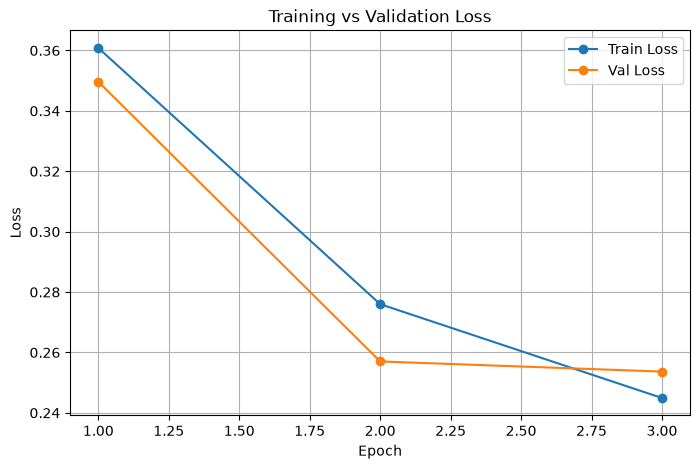

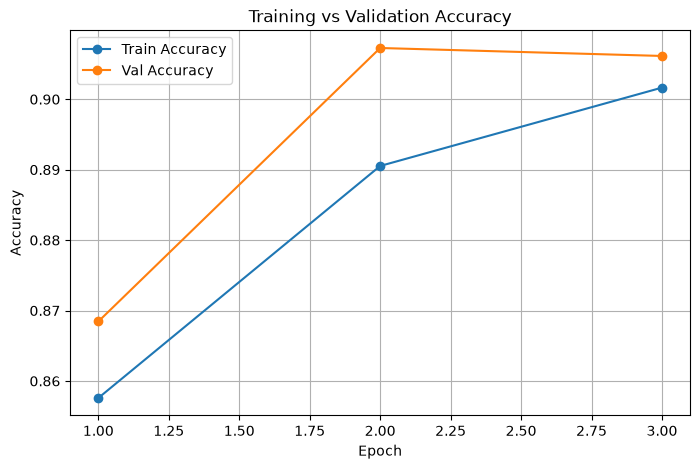

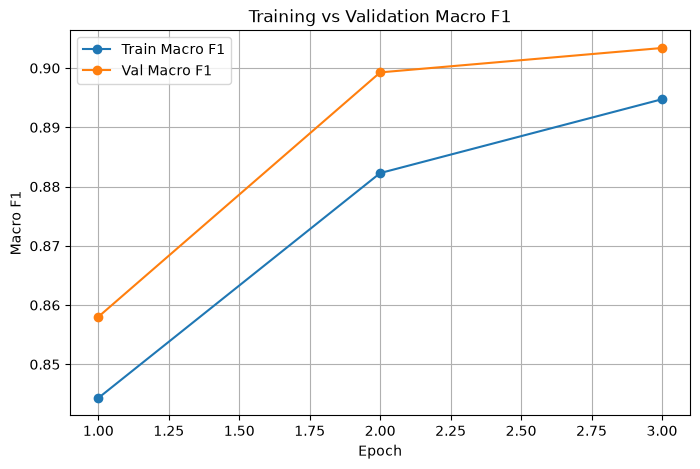

In [46]:
# ============================================================
# CELL 10 — VISUALISASI HISTORY TRAINING
# ============================================================

history_df = pd.DataFrame(history)

display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_f1"], marker="o", label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val Macro F1")
plt.title("Training vs Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(True)
plt.show()

## Evaluasi Model

Final Validation Accuracy: 0.9061
Final Validation Macro F1: 0.9034

Classification Report:
              precision    recall  f1-score   support

0_Recyclable     0.8691    0.9160    0.8919      2000
1_Electronic     0.8464    0.9533    0.8967       792
   2_Organic     0.9631    0.8835    0.9216      2514

    accuracy                         0.9061      5306
   macro avg     0.8929    0.9176    0.9034      5306
weighted avg     0.9103    0.9061    0.9067      5306


Confusion Matrix:
[[1832   87   81]
 [  33  755    4]
 [ 243   50 2221]]


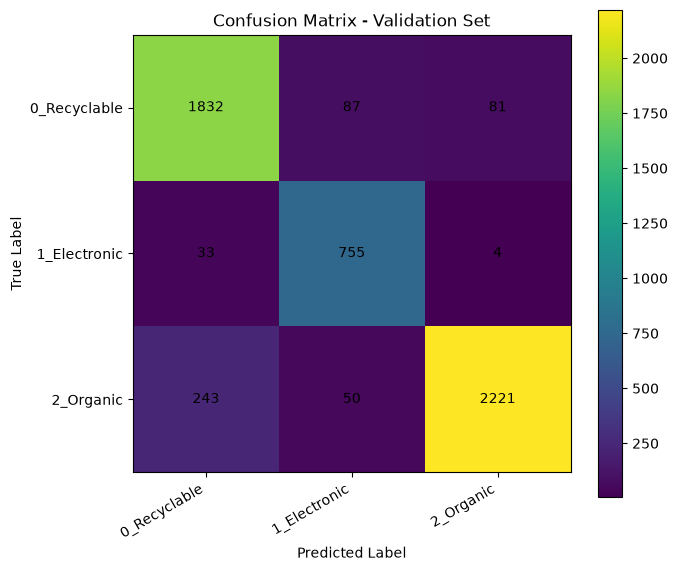

In [47]:
# ============================================================
# CELL 11 — EVALUASI DETAIL MODEL TERBAIK
# ============================================================

model.eval()

final_val_labels = []
final_val_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        final_val_labels.extend(labels.detach().cpu().numpy())
        final_val_preds.extend(preds.detach().cpu().numpy())

final_val_acc = accuracy_score(final_val_labels, final_val_preds)
final_val_f1 = f1_score(final_val_labels, final_val_preds, average="macro")

print("Final Validation Accuracy:", round(final_val_acc, 4))
print("Final Validation Macro F1:", round(final_val_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        final_val_labels,
        final_val_preds,
        target_names=CLASS_NAMES,
        digits=4
    )
)

cm = confusion_matrix(final_val_labels, final_val_preds)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks=np.arange(NUM_CLASSES), labels=CLASS_NAMES, rotation=30, ha="right")
plt.yticks(ticks=np.arange(NUM_CLASSES), labels=CLASS_NAMES)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# CEK APA VARIABLE TRAINING MASIH ADA DI MEMORY
# ============================================================

needed_vars = [
    "torch",
    "model",
    "MODEL_DIR",
    "MODEL_NAME",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "label_to_class",
    "class_to_label",
    "IMG_SIZE",
    "best_val_f1",
    "best_val_loss",
    "history"
]

for var_name in needed_vars:
    print(var_name, ":", var_name in globals())

torch : True
model : True
MODEL_DIR : True
MODEL_NAME : True
NUM_CLASSES : True
CLASS_NAMES : True
label_to_class : True
class_to_label : True
IMG_SIZE : True
best_val_f1 : True
best_val_loss : True
history : True


In [49]:
# ============================================================
# CELL 12A — SET ULANG FOLDER MODEL
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_DIR   :", MODEL_DIR)

PROJECT_ROOT: c:\BDC2026
MODEL_DIR   : c:\BDC2026\models


In [50]:
# ============================================================
# CELL 12 — SAVE MODEL BASELINE
# ============================================================

baseline_model_path = MODEL_DIR / "mobilenetv3_small_baseline_best.pth"

torch.save({
    "model_name": MODEL_NAME,
    "model_state_dict": model.state_dict(),
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "label_to_class": label_to_class,
    "class_to_label": class_to_label,
    "img_size": IMG_SIZE,
    "best_val_f1": best_val_f1,
    "best_val_loss": best_val_loss,
    "history": history
}, baseline_model_path)

print("Model baseline berhasil disimpan di:")
print(baseline_model_path)

print("\nInformasi model:")
print("Model name   :", MODEL_NAME)
print("Best Val F1  :", best_val_f1)
print("Best Val Loss:", best_val_loss)
print("Classes      :", CLASS_NAMES)

Model baseline berhasil disimpan di:
c:\BDC2026\models\mobilenetv3_small_baseline_best.pth

Informasi model:
Model name   : mobilenet_v3_small
Best Val F1  : 0.9033898520608074
Best Val Loss: 0.253664579165238
Classes      : ['0_Recyclable', '1_Electronic', '2_Organic']


In [51]:
# ============================================================
# CELL 13 — PREDIKSI DATA TEST
# ============================================================

model.eval()

test_filenames = []
test_pred_labels = []
test_pred_classes = []
test_confidences = []
test_probabilities = []

if tqdm is not None:
    data_iterator = tqdm(test_loader, desc="Predicting Test", leave=False)
else:
    data_iterator = test_loader

with torch.no_grad():
    for images, filenames in data_iterator:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, preds = torch.max(probabilities, dim=1)

        test_filenames.extend(list(filenames))
        test_pred_labels.extend(preds.detach().cpu().numpy())
        test_confidences.extend(confidences.detach().cpu().numpy())
        test_probabilities.extend(probabilities.detach().cpu().numpy())

test_predictions_df = pd.DataFrame({
    "filename": test_filenames,
    "pred_label": test_pred_labels,
    "pred_class": [label_to_class[int(label)] for label in test_pred_labels],
    "confidence": test_confidences
})

test_predictions_df["file_stem"] = test_predictions_df["filename"].apply(lambda x: Path(str(x)).stem)
test_predictions_df["file_number"] = test_predictions_df["file_stem"].astype(int)

# Tambahkan probabilitas tiap kelas
probability_df = pd.DataFrame(
    test_probabilities,
    columns=[f"prob_{class_name}" for class_name in CLASS_NAMES]
)

test_predictions_df = pd.concat(
    [test_predictions_df, probability_df],
    axis=1
)

print("Jumlah data test:", len(test_predictions_df))
print("\nContoh hasil prediksi:")
display(test_predictions_df.head())

print("\nDistribusi prediksi kelas test:")
display(test_predictions_df["pred_class"].value_counts().sort_index())

# Simpan hasil prediksi lengkap
PREDICTION_DIR = OUTPUT_DIR / "predictions"
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

test_prediction_path = PREDICTION_DIR / "mobilenetv3_small_baseline_test_predictions.csv"
test_predictions_df.to_csv(test_prediction_path, index=False)

print("\nHasil prediksi lengkap berhasil disimpan di:")
print(test_prediction_path)

print("Urutan hasil prediksi test sudah naik?:", test_predictions_df["file_number"].is_monotonic_increasing)
display(test_predictions_df[["filename", "file_number", "pred_label", "pred_class", "confidence"]].head(20))

Predicting Test:   0%|          | 0/46 [00:00<?, ?it/s]

Jumlah data test: 1458

Contoh hasil prediksi:


,filename,pred_label,pred_class,confidence,file_stem,file_number,prob_0_Recyclable,prob_1_Electronic,prob_2_Organic
0,1.jpg,2,2_Organic,0.973068,1,1,0.026607,0.000325,0.973068
1,2.jpg,2,2_Organic,0.676523,2,2,0.323474,0.000002,0.676523
2,3.jpg,2,2_Organic,0.995194,3,3,0.004309,0.000498,0.995194
3,4.jpg,1,1_Electronic,0.999997,4,4,0.000002,0.999997,0.000001
4,5.jpg,0,0_Recyclable,0.855564,5,5,0.855564,0.139660,0.004776



Distribusi prediksi kelas test:


pred_class
0_Recyclable    473
1_Electronic    270
2_Organic       715
Name: count, dtype: int64


Hasil prediksi lengkap berhasil disimpan di:
C:\BDC2026\output\predictions\mobilenetv3_small_baseline_test_predictions.csv
Urutan hasil prediksi test sudah naik?: True


,filename,file_number,pred_label,pred_class,confidence
0,1.jpg,1,2,2_Organic,0.973068
1,2.jpg,2,2,2_Organic,0.676523
2,3.jpg,3,2,2_Organic,0.995194
3,4.jpg,4,1,1_Electronic,0.999997
4,5.jpg,5,0,0_Recyclable,0.855564
5,6.jpg,6,2,2_Organic,0.616671
6,7.jpg,7,2,2_Organic,0.997172
7,8.jpg,8,0,0_Recyclable,0.619571
8,9.jpg,9,1,1_Electronic,0.998904
9,10.jpg,10,2,2_Organic,0.939745


In [52]:
# ============================================================
# CELL 14 — CEK FORMAT FILE SUBMISSION
# ============================================================

possible_submission_files = []

search_dirs = [
    PROJECT_ROOT,
    DATA_DIR,
    DATA_DIR / "submission",
    SUBMISSION_DIR
]

for folder in search_dirs:
    if folder.exists():
        possible_submission_files.extend(list(folder.glob("*.csv")))
        possible_submission_files.extend(list(folder.glob("*.xlsx")))
        possible_submission_files.extend(list(folder.glob("*.xls")))

print("File kandidat submission yang ditemukan:")

if len(possible_submission_files) == 0:
    print("Tidak ada file submission template yang ditemukan.")
else:
    for i, file_path in enumerate(possible_submission_files):
        print(f"{i}. {file_path}")

    sample_submission_path = possible_submission_files[0]

    print("\nFile yang dibaca sebagai contoh format:")
    print(sample_submission_path)

    if sample_submission_path.suffix.lower() == ".csv":
        sample_submission_df = pd.read_csv(sample_submission_path)
    else:
        sample_submission_df = pd.read_excel(sample_submission_path)

    print("\nShape sample submission:")
    print(sample_submission_df.shape)

    print("\nKolom sample submission:")
    print(sample_submission_df.columns.tolist())

    print("\nContoh isi sample submission:")
    display(sample_submission_df.head())

File kandidat submission yang ditemukan:
0. C:\BDC2026\data\submission.csv
1. C:\BDC2026\submission\submission_mobilenetv3_small_baseline.csv
2. C:\BDC2026\submission\submission_SD2026040000144.csv

File yang dibaca sebagai contoh format:
C:\BDC2026\data\submission.csv

Shape sample submission:
(1458, 2)

Kolom sample submission:
['id', 'predicted']

Contoh isi sample submission:


,id,predicted
0,1,NaN
1,2,NaN
2,3,NaN
3,4,NaN
4,5,NaN


In [57]:
# ============================================================
# CELL 15 — GENERATE SUBMISSION CSV
# ============================================================

if "test_predictions_df" not in globals():
    raise NameError("test_predictions_df belum ada. Jalankan Cell 13 terlebih dahulu.")

# Jika sample_submission_df belum ada, buat format default sederhana
if "sample_submission_df" not in globals():
    print("sample_submission_df belum ditemukan.")
    print("Membuat submission default dengan kolom: filename, label")

    submission_df = test_predictions_df[["filename", "pred_label"]].copy()
    submission_df = submission_df.rename(columns={"pred_label": "label"})

else:
    submission_df = sample_submission_df.copy()

    print("Menggunakan template submission dari panitia.")
    print("Kolom template:", submission_df.columns.tolist())

    # Kandidat kolom ID / filename
    id_column_candidates = [
        "filename", "file_name", "image", "image_id", "id", "ID",
        "Filename", "FileName", "Image", "ImageID"
    ]

    id_col = None
    for col in id_column_candidates:
        if col in submission_df.columns:
            id_col = col
            break

    if id_col is None:
        id_col = submission_df.columns[0]
        print(f"Kolom ID tidak terdeteksi dari nama umum. Menggunakan kolom pertama: {id_col}")
    else:
        print("Kolom ID terdeteksi:", id_col)

    # Kandidat kolom target / label
    target_column_candidates = [
        "label", "Label", "class", "Class", "category", "Category",
        "prediction", "Prediction", "target", "Target"
    ]

    target_col = None
    for col in target_column_candidates:
        if col in submission_df.columns and col != id_col:
            target_col = col
            break

    if target_col is None:
        if len(submission_df.columns) >= 2:
            target_col = [col for col in submission_df.columns if col != id_col][0]
            print(f"Kolom target tidak terdeteksi dari nama umum. Menggunakan kolom: {target_col}")
        else:
            raise ValueError("Template submission hanya punya satu kolom. Tidak ditemukan kolom target untuk prediksi.")
    else:
        print("Kolom target terdeteksi:", target_col)

    # Buat mapping prediksi berdasarkan filename lengkap
    pred_label_by_filename = dict(
        zip(test_predictions_df["filename"], test_predictions_df["pred_label"])
    )

    pred_class_by_filename = dict(
        zip(test_predictions_df["filename"], test_predictions_df["pred_class"])
    )

    # Buat mapping tambahan berdasarkan stem/nama tanpa ekstensi
    test_predictions_df["file_stem"] = test_predictions_df["filename"].apply(lambda x: Path(str(x)).stem)

    pred_label_by_stem = dict(
        zip(test_predictions_df["file_stem"], test_predictions_df["pred_label"])
    )

    pred_class_by_stem = dict(
        zip(test_predictions_df["file_stem"], test_predictions_df["pred_class"])
    )

    # Tentukan apakah target sebaiknya angka label atau nama kelas
    sample_target_values = submission_df[target_col].dropna().astype(str).unique().tolist()

    use_class_name = False

    for value in sample_target_values:
        if value in CLASS_NAMES:
            use_class_name = True
            break

    print("Output target menggunakan:", "nama kelas" if use_class_name else "label angka")

    filled_predictions = []
    missing_ids = []

    for item_id in submission_df[id_col].astype(str):
        item_name = Path(item_id).name
        item_stem = Path(item_id).stem

        if use_class_name:
            if item_name in pred_class_by_filename:
                filled_predictions.append(pred_class_by_filename[item_name])
            elif item_stem in pred_class_by_stem:
                filled_predictions.append(pred_class_by_stem[item_stem])
            else:
                filled_predictions.append(None)
                missing_ids.append(item_id)
        else:
            if item_name in pred_label_by_filename:
                filled_predictions.append(int(pred_label_by_filename[item_name]))
            elif item_stem in pred_label_by_stem:
                filled_predictions.append(int(pred_label_by_stem[item_stem]))
            else:
                filled_predictions.append(None)
                missing_ids.append(item_id)

    submission_df[target_col] = filled_predictions

    if len(missing_ids) > 0:
        print("\nWARNING: Ada ID/file di template yang tidak cocok dengan prediksi test.")
        print("Jumlah missing:", len(missing_ids))
        print("Contoh missing:", missing_ids[:10])
    else:
        print("\nSemua ID/file pada template berhasil dicocokkan dengan prediksi test.")

# Simpan submission
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

submission_path = SUBMISSION_DIR / f"submission_SD2026040000144_fixed_{timestamp}.csv"
submission_df.to_csv(submission_path, index=False)

print("Submission berhasil dibuat:")
print(submission_path)
print("\nSubmission berhasil dibuat:")
print(submission_path)

print("\nShape submission:")
print(submission_df.shape)

print("\nContoh submission:")
display(submission_df.head())

print("\nDistribusi label/class pada submission:")
last_col = submission_df.columns[-1]
display(submission_df[last_col].value_counts().sort_index())

Menggunakan template submission dari panitia.
Kolom template: ['id', 'predicted']
Kolom ID terdeteksi: id
Kolom target tidak terdeteksi dari nama umum. Menggunakan kolom: predicted
Output target menggunakan: label angka

Semua ID/file pada template berhasil dicocokkan dengan prediksi test.
Submission berhasil dibuat:
C:\BDC2026\submission\submission_SD2026040000144_fixed_20260718_200433.csv

Submission berhasil dibuat:
C:\BDC2026\submission\submission_SD2026040000144_fixed_20260718_200433.csv

Shape submission:
(1458, 2)

Contoh submission:


,id,predicted
0,1,2
1,2,2
2,3,2
3,4,1
4,5,0



Distribusi label/class pada submission:


predicted
0    473
1    270
2    715
Name: count, dtype: int64

In [58]:
# ============================================================
# CELL 16 — CEK ULANG FILE SUBMISSION
# ============================================================

if "submission_path" not in globals():
    submission_path = SUBMISSION_DIR / "submission_SD2026040000144.csv"

if not submission_path.exists():
    raise FileNotFoundError(f"File submission tidak ditemukan: {submission_path}")

final_submission_df = pd.read_csv(submission_path)

print("File submission:")
print(submission_path)

print("\nShape submission:")
print(final_submission_df.shape)

print("\nKolom submission:")
print(final_submission_df.columns.tolist())

print("\nJumlah missing value per kolom:")
display(final_submission_df.isna().sum())

print("\nContoh isi submission:")
display(final_submission_df.head())

print("\nContoh isi submission bagian akhir:")
display(final_submission_df.tail())

# Cek duplikat pada kolom pertama, biasanya ID/filename
id_col = final_submission_df.columns[0]
target_col = final_submission_df.columns[-1]

duplicate_count = final_submission_df[id_col].duplicated().sum()

print("\nKolom ID yang dicek :", id_col)
print("Kolom target        :", target_col)
print("Jumlah duplikat ID  :", duplicate_count)

print("\nDistribusi prediksi:")
display(final_submission_df[target_col].value_counts().sort_index())

# Bandingkan jumlah baris dengan test data
if "test_df" in globals():
    print("\nJumlah data test      :", len(test_df))
    print("Jumlah baris submission:", len(final_submission_df))

    if len(test_df) == len(final_submission_df):
        print("Jumlah baris submission sudah sesuai dengan data test.")
    else:
        print("WARNING: Jumlah baris submission berbeda dengan data test.")

# Bandingkan dengan template submission jika ada
if "sample_submission_df" in globals():
    print("\nJumlah baris template submission:", len(sample_submission_df))

    if len(sample_submission_df) == len(final_submission_df):
        print("Jumlah baris submission sesuai dengan template.")
    else:
        print("WARNING: Jumlah baris submission berbeda dengan template.")

    if list(sample_submission_df.columns) == list(final_submission_df.columns):
        print("Kolom submission sesuai dengan template.")
    else:
        print("WARNING: Kolom submission berbeda dengan template.")

File submission:
C:\BDC2026\submission\submission_SD2026040000144_fixed_20260718_200433.csv

Shape submission:
(1458, 2)

Kolom submission:
['id', 'predicted']

Jumlah missing value per kolom:


id           0
predicted    0
dtype: int64


Contoh isi submission:


,id,predicted
0,1,2
1,2,2
2,3,2
3,4,1
4,5,0



Contoh isi submission bagian akhir:


,id,predicted
1453,1454,2
1454,1455,2
1455,1456,0
1456,1457,2
1457,1458,0



Kolom ID yang dicek : id
Kolom target        : predicted
Jumlah duplikat ID  : 0

Distribusi prediksi:


predicted
0    473
1    270
2    715
Name: count, dtype: int64


Jumlah data test      : 1458
Jumlah baris submission: 1458
Jumlah baris submission sudah sesuai dengan data test.

Jumlah baris template submission: 1458
Jumlah baris submission sesuai dengan template.
Kolom submission sesuai dengan template.


In [59]:
# ============================================================
# CEK APA SUBMISSION SUDAH SESUAI KETENTUAN PANITIA
# ============================================================

final_submission_df = pd.read_csv(submission_path)

print("Nama file submission:")
print(submission_path.name)

print("\nKolom:")
print(final_submission_df.columns.tolist())

print("\nShape:")
print(final_submission_df.shape)

print("\nMissing value:")
display(final_submission_df.isna().sum())

print("\nDistribusi predicted:")
if "predicted" in final_submission_df.columns:
    display(final_submission_df["predicted"].value_counts().sort_index())
else:
    print("Kolom 'predicted' tidak ditemukan.")

print("\nCek nilai unik target:")
if "predicted" in final_submission_df.columns:
    print(sorted(final_submission_df["predicted"].unique()))

# Validasi sederhana
is_name_ok = submission_path.name.startswith("submission_") and submission_path.suffix == ".csv"
is_columns_ok = final_submission_df.columns.tolist() == ["id", "predicted"]
is_rows_ok = len(final_submission_df) == 1458
is_no_missing = final_submission_df.isna().sum().sum() == 0

if "predicted" in final_submission_df.columns:
    is_label_ok = set(final_submission_df["predicted"].unique()).issubset({0, 1, 2})
else:
    is_label_ok = False

print("\nHASIL CEK:")
print("Nama file benar        :", is_name_ok)
print("Kolom benar            :", is_columns_ok)
print("Jumlah baris benar     :", is_rows_ok)
print("Tidak ada missing      :", is_no_missing)
print("Label hanya 0,1,2      :", is_label_ok)

if all([is_name_ok, is_columns_ok, is_rows_ok, is_no_missing, is_label_ok]):
    print("\nSubmission sudah sesuai format dasar ketentuan panitia.")
else:
    print("\nSubmission belum sepenuhnya sesuai. Perlu diperbaiki.")

Nama file submission:
submission_SD2026040000144_fixed_20260718_200433.csv

Kolom:
['id', 'predicted']

Shape:
(1458, 2)

Missing value:


id           0
predicted    0
dtype: int64


Distribusi predicted:


predicted
0    473
1    270
2    715
Name: count, dtype: int64


Cek nilai unik target:
[np.int64(0), np.int64(1), np.int64(2)]

HASIL CEK:
Nama file benar        : True
Kolom benar            : True
Jumlah baris benar     : True
Tidak ada missing      : True
Label hanya 0,1,2      : True

Submission sudah sesuai format dasar ketentuan panitia.


In [60]:
# ============================================================
# BUAT SUBMISSION FINAL SESUAI TEMPLATE DAN MATCHING ID
# ============================================================

NAMA_TIM = "SD2026040000144"
NAMA_TIM_FILE = NAMA_TIM.strip().replace(" ", "_")

if "sample_submission_df" not in globals():
    raise NameError("sample_submission_df belum ada. Jalankan Cell 14 terlebih dahulu.")

if "test_predictions_df" not in globals():
    raise NameError("test_predictions_df belum ada. Jalankan Cell 13 terlebih dahulu.")

submission_final_df = sample_submission_df.copy()

print("Kolom template:", submission_final_df.columns.tolist())

if submission_final_df.columns.tolist() != ["id", "predicted"]:
    raise ValueError("Kolom template harus ['id', 'predicted'].")

# Siapkan mapping dari nomor file test ke prediksi
pred_map_df = test_predictions_df.copy()

pred_map_df["file_stem"] = pred_map_df["filename"].apply(lambda x: Path(str(x)).stem)
pred_map_df["id"] = pred_map_df["file_stem"].astype(int)
pred_map_df["pred_label"] = pred_map_df["pred_label"].astype(int)

pred_label_map = dict(zip(pred_map_df["id"], pred_map_df["pred_label"]))

# Isi predicted berdasarkan id dari template panitia
submission_final_df["predicted"] = (
    submission_final_df["id"].astype(int).map(pred_label_map)
)

missing_count = submission_final_df["predicted"].isna().sum()
print("Missing predicted:", missing_count)

if missing_count > 0:
    print("Contoh ID yang belum punya prediksi:")
    display(submission_final_df[submission_final_df["predicted"].isna()].head(10))
    raise ValueError("Masih ada id template yang tidak cocok dengan prediksi test.")

submission_final_df["predicted"] = submission_final_df["predicted"].astype(int)

# Validasi akhir
print("\nShape:")
print(submission_final_df.shape)

print("\nKolom:")
print(submission_final_df.columns.tolist())

print("\nNilai unik predicted:")
print(sorted(submission_final_df["predicted"].unique()))

print("\nContoh awal:")
display(submission_final_df.head(20))

print("\nContoh akhir:")
display(submission_final_df.tail(20))

print("\nDistribusi predicted:")
display(submission_final_df["predicted"].value_counts().sort_index())

# Simpan file final
final_submission_path = SUBMISSION_DIR / f"submission_{NAMA_TIM_FILE}_fixed.csv"
submission_final_df.to_csv(final_submission_path, index=False)

print("\nSubmission final berhasil dibuat:")
print(final_submission_path)

Kolom template: ['id', 'predicted']
Missing predicted: 0

Shape:
(1458, 2)

Kolom:
['id', 'predicted']

Nilai unik predicted:
[np.int64(0), np.int64(1), np.int64(2)]

Contoh awal:


,id,predicted
0,1,2
1,2,2
2,3,2
3,4,1
4,5,0
5,6,2
6,7,2
7,8,0
8,9,1
9,10,2



Contoh akhir:


,id,predicted
1438,1439,0
1439,1440,0
1440,1441,0
1441,1442,2
1442,1443,2
1443,1444,0
1444,1445,1
1445,1446,0
1446,1447,2
1447,1448,2



Distribusi predicted:


predicted
0    473
1    270
2    715
Name: count, dtype: int64


Submission final berhasil dibuat:
C:\BDC2026\submission\submission_SD2026040000144_fixed.csv


In [ ]:
# ============================================================
# CELL 2C — FIX URUTAN TEST BERDASARKAN NOMOR FILE
# ============================================================

test_df = test_df.copy()

test_df["file_stem"] = test_df["filename"].apply(lambda x: Path(str(x)).stem)
test_df["file_number"] = test_df["file_stem"].astype(int)

test_df = test_df.sort_values("file_number").reset_index(drop=True)

print("Contoh urutan test setelah diperbaiki:")
display(test_df[["filename", "file_number"]].head(30))

print("\nContoh urutan test bagian akhir:")
display(test_df[["filename", "file_number"]].tail(30))

print("\nJumlah data test:", len(test_df))
print("Nomor file minimum:", test_df["file_number"].min())
print("Nomor file maksimum:", test_df["file_number"].max())
print("Urutan sudah naik?:", test_df["file_number"].is_monotonic_increasing)

Contoh urutan test_df sekarang:


,filename,file_number
0,1.jpg,1
1,10.jpg,10
2,100.jpg,100
3,1000.jpg,1000
4,1001.jpg,1001
5,1002.jpg,1002
6,1003.jpg,1003
7,1004.jpg,1004
8,1005.jpg,1005
9,1006.jpg,1006



Contoh urutan test_df bagian akhir:


,filename,file_number
1428,972.jpg,972
1429,973.jpg,973
1430,974.jpg,974
1431,975.jpg,975
1432,976.jpg,976
1433,977.jpg,977
1434,978.jpg,978
1435,979.jpg,979
1436,98.jpg,98
1437,980.jpg,980



Jumlah data test: 1458
Nomor file minimum: 1
Nomor file maksimum: 1458

Apakah file_number sudah urut naik?
False


In [61]:
# ============================================================
# FINAL CHECK SUBMISSION FIXED
# ============================================================

final_check_path = SUBMISSION_DIR / "submission_SD2026040000144_fixed.csv"

final_check_df = pd.read_csv(final_check_path)

print("Path:", final_check_path)
print("Shape:", final_check_df.shape)
print("Kolom:", final_check_df.columns.tolist())

print("\nMissing value:")
display(final_check_df.isna().sum())

print("\nNilai unik predicted:")
print(sorted(final_check_df["predicted"].unique()))

print("\nDistribusi predicted:")
display(final_check_df["predicted"].value_counts().sort_index())

print("\nCek ID:")
print("ID min:", final_check_df["id"].min())
print("ID max:", final_check_df["id"].max())
print("ID berurutan naik?:", final_check_df["id"].is_monotonic_increasing)
print("Jumlah duplikat ID:", final_check_df["id"].duplicated().sum())

display(final_check_df.head(20))
display(final_check_df.tail(20))

Path: C:\BDC2026\submission\submission_SD2026040000144_fixed.csv
Shape: (1458, 2)
Kolom: ['id', 'predicted']

Missing value:


id           0
predicted    0
dtype: int64


Nilai unik predicted:
[np.int64(0), np.int64(1), np.int64(2)]

Distribusi predicted:


predicted
0    473
1    270
2    715
Name: count, dtype: int64


Cek ID:
ID min: 1
ID max: 1458
ID berurutan naik?: True
Jumlah duplikat ID: 0


,id,predicted
0,1,2
1,2,2
2,3,2
3,4,1
4,5,0
5,6,2
6,7,2
7,8,0
8,9,1
9,10,2


,id,predicted
1438,1439,0
1439,1440,0
1440,1441,0
1441,1442,2
1442,1443,2
1443,1444,0
1444,1445,1
1445,1446,0
1446,1447,2
1447,1448,2
